# 1ª Parte – Desenvolvimento Pipeline/Notebook Visual Code

## Configurações

- Instalação e importação de bibiotecas

In [1]:
# Instalação de biblioteca pyodbc e pandas
!pip install pyodbc
!pip install pandas

In [2]:
# importação de biblioteca pyodbc e pandas
import pandas as pd
import pyodbc

## Diagrama dimensional conceitual da tabela vendas

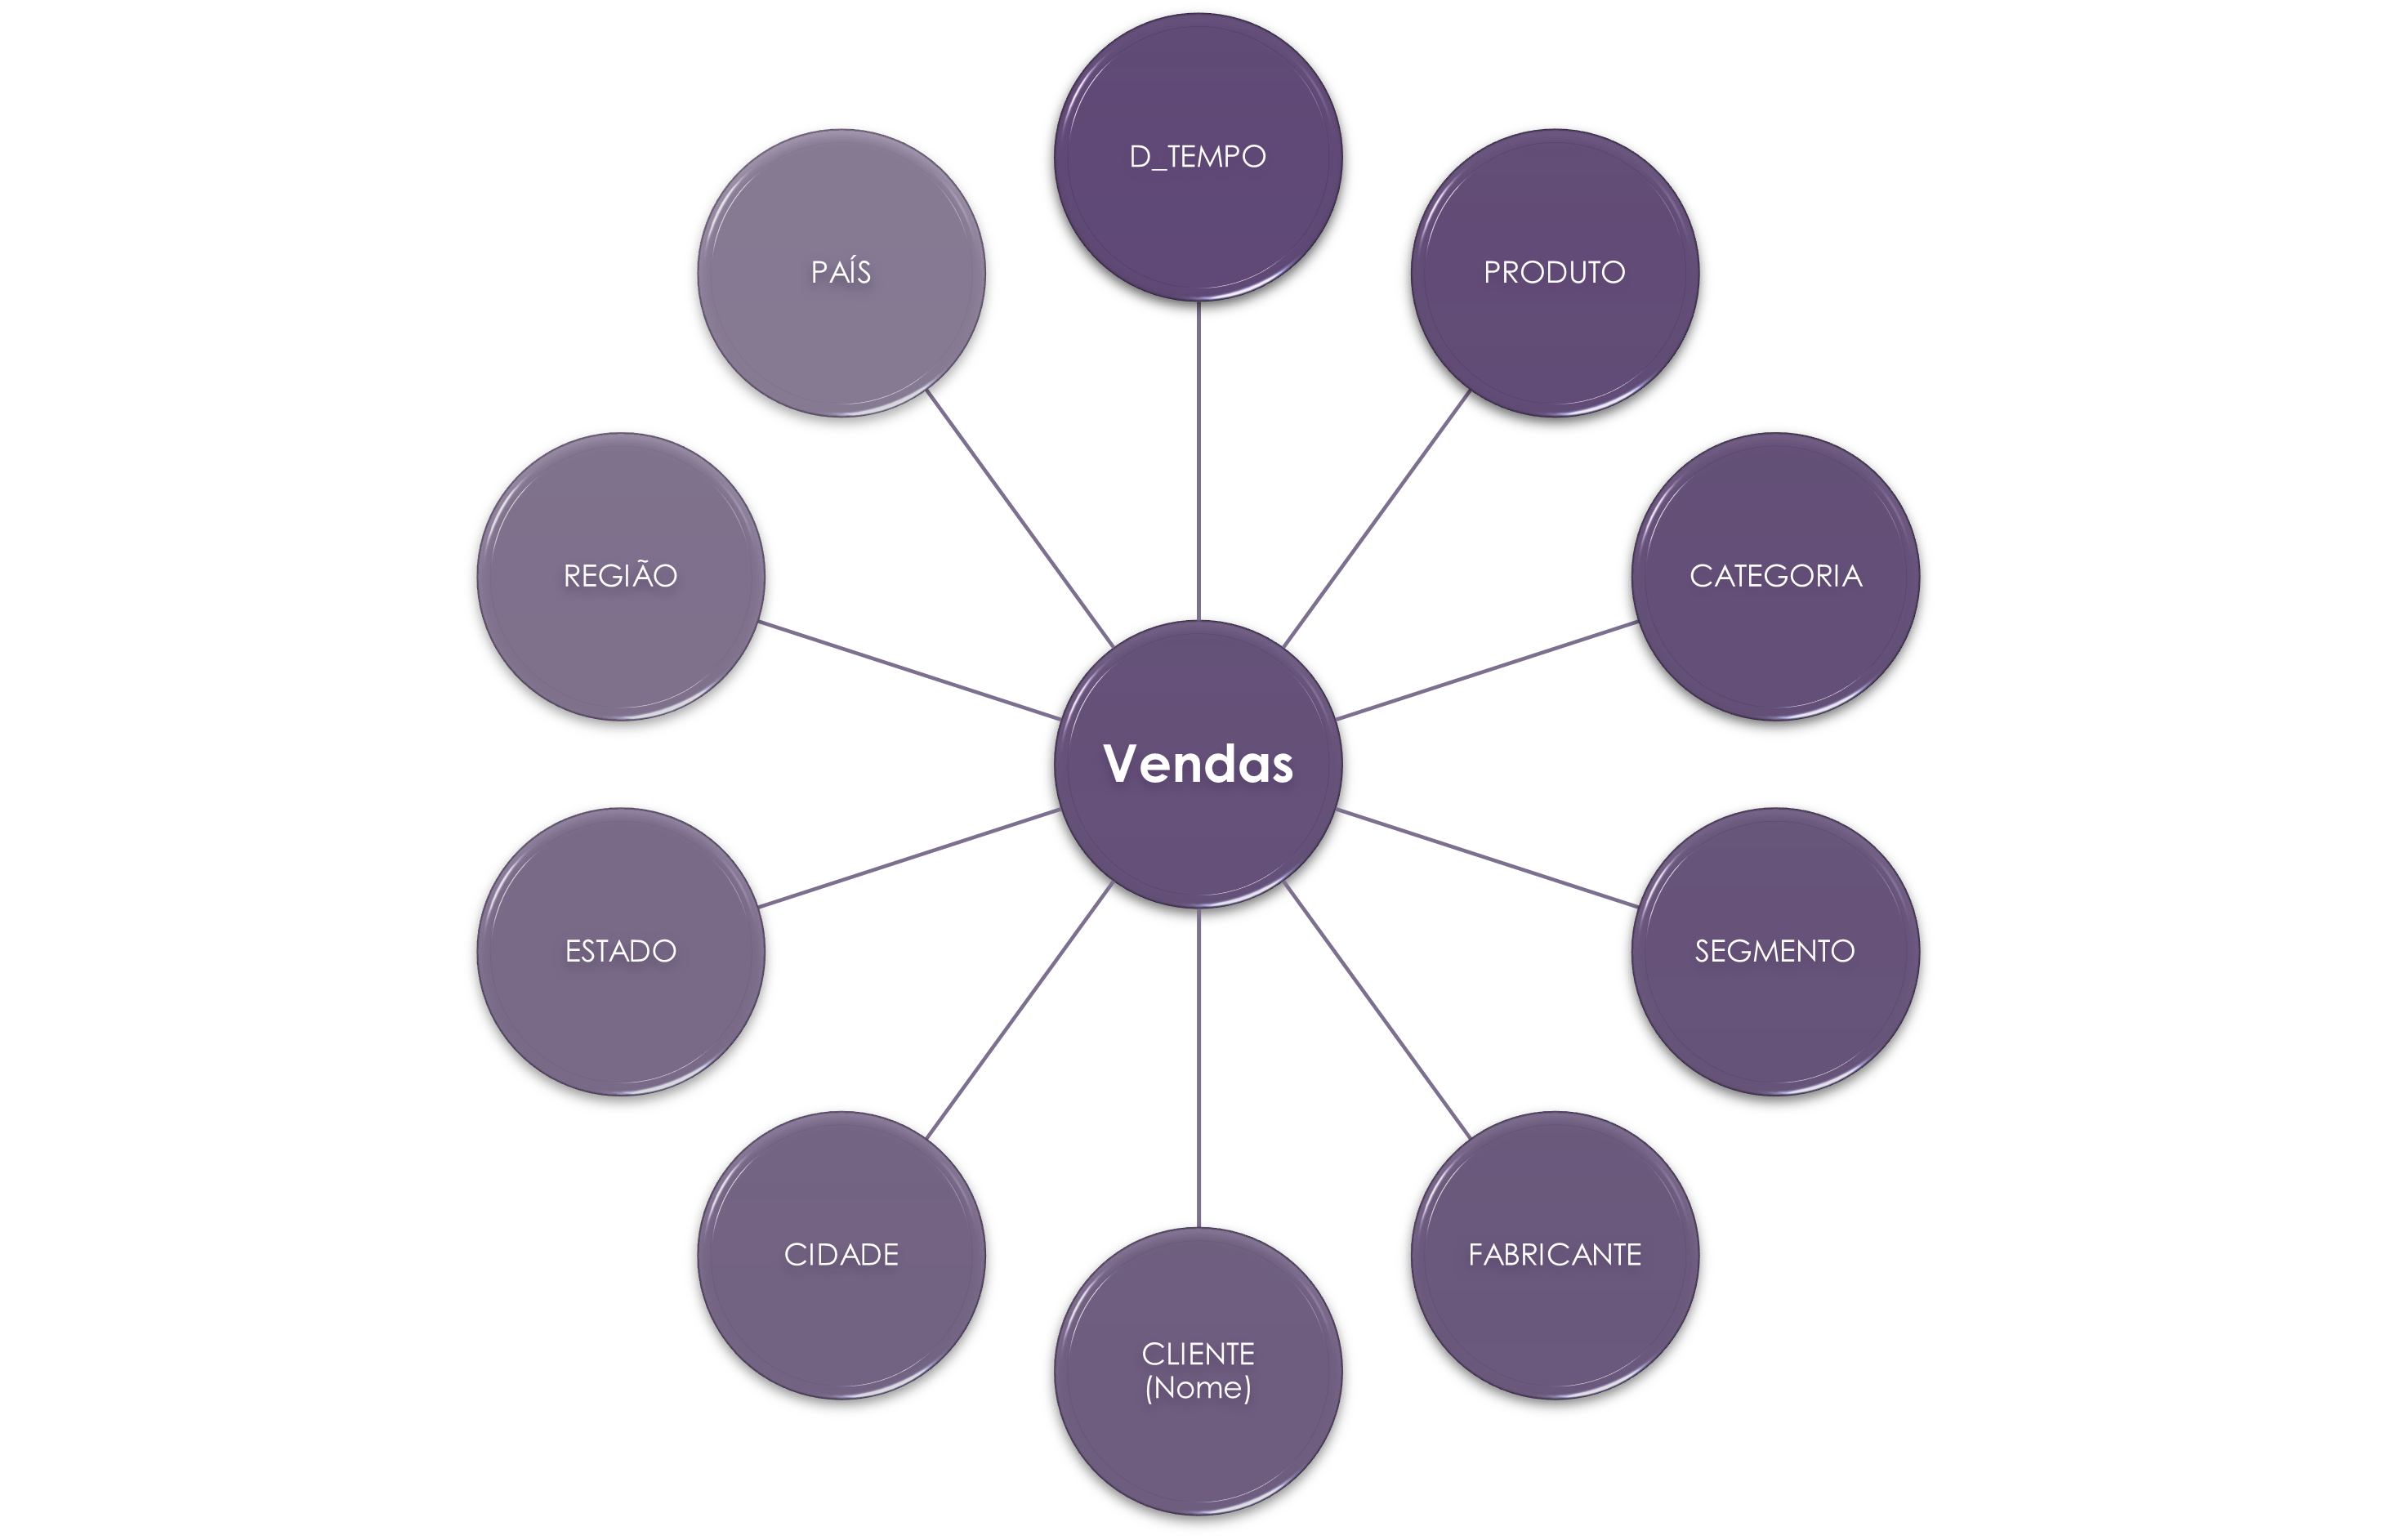

In [3]:
#Instalando bibliteca pillow
!pip install pillow

#Importando biblioteca pillow
from PIL import Image,ImageEnhance

#Mostrando Imagem
img_original = Image.open("imagem1.png")
display(img_original)


## 2 - Construção da camada Silver
 - Transformação dos arquivos em formato parquet
 - Tratamento da coluna nome
 - Tratamento da coluna cidade
 - Tratamento da coluna data
 - Remoção de colunas

In [ ]:
# Lendo um arquivo CSV da camada bronze
df =  pd.read_csv(r"BRONZE\Vendas.csv")

# Exibindo o DataFrame
print(df)

        IDProduto                     Data  IDCliente  IDCampanha  Unidades  \
0             449  2012-07-26 00:00:00.000     247546          22         1   
1             449  2013-10-31 00:00:00.000     124593          22         1   
2             449  2013-11-14 00:00:00.000     163517          22         1   
3             449  2013-01-17 00:00:00.000       8875          18         1   
4             449  2014-09-13 00:00:00.000       8894          21         1   
...           ...                      ...        ...         ...       ...   
675363        407  2012-05-20 00:00:00.000      32464           3         1   
675364        407  2011-03-02 00:00:00.000      32441           5         1   
675365        407  2012-06-02 00:00:00.000     101533           1         1   
675366        407  2011-04-10 00:00:00.000     147192           4         1   
675367        407  2012-03-01 00:00:00.000     237766           3         1   

              Produto  Categoria    Segmento  IDFab

In [5]:
# Separando e-mail de nome
df[['Email','Nome']] = df['EmailNome'].str.split(':', expand=True)

# Remove parênteses do email
df['Email'] = df['Email'].str.replace('(','')
df['Email'] = df['Email'].str.replace(')','')


# Exibindo colunas separadas
print(df[['EmailNome','Email','Nome']])

                                                EmailNome  \
0                    (Nerea.Barry@xyza.com): Barry, Nerea   
1              (Elliott.Stuart@xyza.com): Stuart, Elliott   
2              (Holmes.Swanson@xyza.com): Swanson, Holmes   
3                    (Nyssa.Solis@xyza.com): Solis, Nyssa   
4                      (Ivana.Wall@xyza.com): Wall, Ivana   
...                                                   ...   
675363  (Catherine.Martinez@xyza.com): Martinez, Cathe...   
675364             (Dora.Emerson@xyza.com): Emerson, Dora   
675365                 (Lynn.Jones@xyza.com): Jones, Lynn   
675366         (Maite.Cantrell@xyza.com): Cantrell, Maite   
675367           (Yolanda.Byers@xyza.com): Byers, Yolanda   

                              Email                  Nome  
0              Nerea.Barry@xyza.com          Barry, Nerea  
1           Elliott.Stuart@xyza.com       Stuart, Elliott  
2           Holmes.Swanson@xyza.com       Swanson, Holmes  
3              Nyssa.Solis@

In [6]:
# Tratar a coluna cidade, mantendo apenas o nome da cidade
df[['Cidade','EstadoPais']] = df['Cidade'].str.split(',', expand=True, n=1)

# Exibindo colunas separadas
print(df[['Cidade', 'EstadoPais']])

                   Cidade EstadoPais
0                   Miami    FL, USA
1                   Miami    FL, USA
2                   Miami    FL, USA
3                   Miami    FL, USA
4                   Miami    FL, USA
...                   ...        ...
675363        Panama City    FL, USA
675364        Panama City    FL, USA
675365          Pensacola    FL, USA
675366  Panama City Beach    FL, USA
675367           Fountain    FL, USA

[675368 rows x 2 columns]


In [7]:
# Tratando a coluna data
# Conversão em Data
df['Data'] = pd.to_datetime(df.Data)

# Formatação da Data
df['Data'] = df['Data'].dt.strftime('%d/%m/%Y')

In [8]:
# Eliminar as colunas IDCampanha, distrito, código postal e colunas de IDs
df_original = df.drop(['IDCampanha', 'Distrito', 'CodigoPostal', 'IDProduto', 'IDCliente', 'IDFabricante', 'EmailNome', 'EstadoPais', 'Email'], axis = 1)
df_original = df.reindex(['Data','Unidades','Produto','Categoria', 'Segmento', 'Fabricante','CustoUnitario', 'PrecoUnitario', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Pais'], axis=1)

# Exibindo o DataFrame
df_original

,Data,Unidades,Produto,Categoria,Segmento,Fabricante,CustoUnitario,PrecoUnitario,Nome,Cidade,Estado,Regiao,Pais
0,26/07/2012,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Barry, Nerea",Miami,FL,East,USA
1,31/10/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Stuart, Elliott",Miami,FL,East,USA
2,14/11/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Swanson, Holmes",Miami,FL,East,USA
3,17/01/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Solis, Nyssa",Miami,FL,East,USA
4,13/09/2014,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Wall, Ivana",Miami,FL,East,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,20/05/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Martinez, Catherine",Panama City,FL,East,USA
675364,02/03/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Emerson, Dora",Panama City,FL,East,USA
675365,02/06/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Jones, Lynn",Pensacola,FL,East,USA
675366,10/04/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Cantrell, Maite",Panama City Beach,FL,East,USA


In [9]:
# Criação de DataFrame_Produto
df_original_Produto = df_original.drop_duplicates(subset="Produto").drop(['Data','Categoria', 'Segmento', 'Fabricante', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Produto

,Produto
0,Maximus UM-54
63966,Maximus UM-75
80748,Maximus UM-01
90775,Maximus UM-62
97790,Maximus UM-38
...,...
636158,Maximus RS-01
636160,Maximus RP-01
636167,Maximus RP-02
636298,Maximus UM-05


In [10]:
# Criação de DataFrame_Categoria
df_original_Categoria = df_original.drop_duplicates(subset="Categoria").drop(['Data','Produto', 'Segmento', 'Fabricante', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Categoria

,Categoria
0,Urban
564679,Mix
620517,Youth
636158,Rural
636199,Accessory


In [11]:
# Criação de DataFrame_Segmento
df_original_Segmento = df_original.drop_duplicates(subset="Segmento").drop(['Data','Produto','Categoria', 'Fabricante', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Segmento

,Segmento
0,Moderation
366571,Convenience
558200,Extreme
563908,Regular
564679,All Season
582584,Productivity
620517,Youth
636158,Select
636199,Accessory


In [12]:
# Criação de DataFrame_Fabricante
df_original_Fabricante = df_original.drop_duplicates(subset="Fabricante").drop(['Data','Produto','Categoria', 'Segmento', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Fabricante

,Fabricante
0,VanArsdel


In [13]:
# Criação de DataFrame_Cidade
df_original_Cidade = df_original.drop_duplicates(subset="Cidade").drop(['Data','Produto','Categoria', 'Segmento', 'Fabricante', 'Nome', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Cidade

,Cidade
0,Miami
186,Fort Lauderdale
335,Port Saint Lucie
421,Fort Myers
500,Tampa
...,...
672658,Sassafras
672669,Mayking
672717,Gunlock
673458,Clairfield


In [14]:
# Criação de DataFrame_Estado
df_original_Estado = df_original.drop_duplicates(subset="Estado").drop(['Data','Produto','Categoria', 'Segmento', 'Fabricante', 'Nome', 'Cidade', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Estado

,Estado
0,FL
4341,OH
8023,PA
10961,NY
13211,MI
15417,NC
17531,IN
19299,GA
20869,NJ
21883,SC


In [15]:
# Criação de DataFrame_Regiao
df_original_Regiao = df_original.drop_duplicates(subset="Regiao").drop(['Data','Produto','Categoria', 'Segmento', 'Fabricante', 'Nome', 'Cidade', 'Estado', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Regiao

,Regiao
0,East
31140,Central
55267,West


In [16]:
# Criação de DataFrame_Pais
df_original_Pais = df_original.drop_duplicates(subset="Pais").drop(['Data','Produto','Categoria', 'Segmento', 'Fabricante', 'Nome', 'Cidade', 'Estado', 'Regiao', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Pais

,Pais
0,USA


In [17]:
# Criação de DataFrame_Cliente
df_original_Cliente = df_original.drop_duplicates(subset="Nome").drop(['Data','Produto','Categoria', 'Segmento', 'Fabricante', 'Cidade', 'Estado', 'Regiao', 'Pais', 'Unidades', 'CustoUnitario', 'PrecoUnitario'], axis = 1)

# Exibindo o DataFrame
df_original_Cliente

,Nome
0,"Barry, Nerea"
1,"Stuart, Elliott"
2,"Swanson, Holmes"
3,"Solis, Nyssa"
4,"Wall, Ivana"
...,...
675127,"Guthrie, Nichole"
675269,"Sloan, Kirestin"
675308,"Floyd, Venus"
675322,"Williams, Patience"


In [18]:
# Instalação da biblioteca pyarrow para conversão de dados em parquet
!pip install pyarrow

In [ ]:
# conversão das dimensões e vendas em parquet
df_original.to_parquet(r"SILVER\df_original.parquet", index=False)
df_original_Produto.to_parquet(r"SILVER\df_original_produto.parquet", index=False)
df_original_Categoria.to_parquet(r"SILVER\df_original_categoria.parquet", index=False)
df_original_Segmento.to_parquet(r"SILVER\df_original_segmento.parquet", index=False)
df_original_Fabricante.to_parquet(r"SILVER\df_original_fabricante.parquet", index=False)
df_original_Cidade.to_parquet(r"SILVER\df_original_cidade.parquet", index=False)
df_original_Estado.to_parquet(r"SILVER\df_original_estado.parquet", index=False)
df_original_Regiao.to_parquet(r"SILVER\df_original_regiao.parquet", index=False)
df_original_Pais.to_parquet(r"SILVER\df_original_pais.parquet", index=False)
df_original_Cliente.to_parquet(r"SILVER\df_original_cliente.parquet", index=False)

In [20]:
# Exibindo o DataFrame
df_original

,Data,Unidades,Produto,Categoria,Segmento,Fabricante,CustoUnitario,PrecoUnitario,Nome,Cidade,Estado,Regiao,Pais
0,26/07/2012,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Barry, Nerea",Miami,FL,East,USA
1,31/10/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Stuart, Elliott",Miami,FL,East,USA
2,14/11/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Swanson, Holmes",Miami,FL,East,USA
3,17/01/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Solis, Nyssa",Miami,FL,East,USA
4,13/09/2014,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Wall, Ivana",Miami,FL,East,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,20/05/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Martinez, Catherine",Panama City,FL,East,USA
675364,02/03/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Emerson, Dora",Panama City,FL,East,USA
675365,02/06/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Jones, Lynn",Pensacola,FL,East,USA
675366,10/04/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Cantrell, Maite",Panama City Beach,FL,East,USA


## 3 - Construção da camada Gold
- Adicionar as SK´s as tabelas dimensões
- Aplicar SCD1 nas dimensões
- Adicionar as SK´s tabela fato
- Particionar os arquivos Parquet da tabela fato em ano e mês

In [ ]:
# Leitura do arquivo parquet, posso chamar o df para usar os dados, ou ler diretamente da camada SILVER
df_original =  pd.read_parquet(r"SILVER\df_original.parquet")

# Exibindo o DataFrame
df_original

,Data,Unidades,Produto,Categoria,Segmento,Fabricante,CustoUnitario,PrecoUnitario,Nome,Cidade,Estado,Regiao,Pais
0,26/07/2012,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Barry, Nerea",Miami,FL,East,USA
1,31/10/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Stuart, Elliott",Miami,FL,East,USA
2,14/11/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Swanson, Holmes",Miami,FL,East,USA
3,17/01/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Solis, Nyssa",Miami,FL,East,USA
4,13/09/2014,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Wall, Ivana",Miami,FL,East,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,20/05/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Martinez, Catherine",Panama City,FL,East,USA
675364,02/03/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Emerson, Dora",Panama City,FL,East,USA
675365,02/06/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Jones, Lynn",Pensacola,FL,East,USA
675366,10/04/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Cantrell, Maite",Panama City Beach,FL,East,USA


In [ ]:
# Leitura da dimensão produto diretamente da camada SILVER
df_original_Produto = pd.read_parquet(r"SILVER\df_original_produto.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_produto = pd.DataFrame(columns=["sk_Produto", "PRODUTO"])

for index, row in df_original_Produto.iterrows():
    new_row = pd.DataFrame({
        "sk_Produto": [df_d_produto.index.max() + 1 if len(df_d_produto) > 0 else 0],
        "PRODUTO": [row["Produto"]]
    })
    df_d_produto = pd.concat([df_d_produto, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_produto)

    sk_Produto        PRODUTO
0            0  Maximus UM-54
1            1  Maximus UM-75
2            2  Maximus UM-01
3            3  Maximus UM-62
4            4  Maximus UM-38
..         ...            ...
168        168  Maximus RS-01
169        169  Maximus RP-01
170        170  Maximus RP-02
171        171  Maximus UM-05
172        172  Maximus UM-07

[173 rows x 2 columns]


In [ ]:
# Leitura da dimensão Categoria diretamente da camada SILVER
df_original_Categoria = pd.read_parquet(r"SILVER\df_original_categoria.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_categoria = pd.DataFrame(columns=["sk_Categoria", "CATEGORIA"])

for index, row in df_original_Categoria.iterrows():
    new_row = pd.DataFrame({
        "sk_Categoria": [df_d_categoria.index.max() + 1 if len(df_d_categoria) > 0 else 0],
        "CATEGORIA": [row["Categoria"]]
    })
    df_d_categoria = pd.concat([df_d_categoria, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_categoria)

  sk_Categoria  CATEGORIA
0            0      Urban
1            1        Mix
2            2      Youth
3            3      Rural
4            4  Accessory


In [ ]:
# Leitura da dimensão Segmento diretamente da camada SILVER
df_original_Segmento = pd.read_parquet(r"SILVER\df_original_segmento.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_segmento = pd.DataFrame(columns=["sk_Segmento", "SEGMENTO"])

for index, row in df_original_Segmento.iterrows():
    new_row = pd.DataFrame({
        "sk_Segmento": [df_d_segmento.index.max() + 1 if len(df_d_segmento) > 0 else 0],
        "SEGMENTO": [row["Segmento"]]
    })
    df_d_segmento = pd.concat([df_d_segmento, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_segmento)

  sk_Segmento      SEGMENTO
0           0    Moderation
1           1   Convenience
2           2       Extreme
3           3       Regular
4           4    All Season
5           5  Productivity
6           6         Youth
7           7        Select
8           8     Accessory


In [ ]:
# Leitura da dimensão Fabricante diretamente da camada SILVER
df_original_Fabricante = pd.read_parquet(r"SILVER\df_original_fabricante.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_fabricante = pd.DataFrame(columns=["sk_Fabricante", "FABRICANTE"])

for index, row in df_original_Fabricante.iterrows():
    new_row = pd.DataFrame({
        "sk_Fabricante": [df_d_fabricante.index.max() + 1 if len(df_d_fabricante) > 0 else 0],
        "FABRICANTE": [row["Fabricante"]]
    })
    df_d_fabricante = pd.concat([df_d_fabricante, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_fabricante)

  sk_Fabricante FABRICANTE
0             0  VanArsdel


In [ ]:
# Leitura da dimensão Cidade diretamente da camada SILVER
df_original_Cidade = pd.read_parquet(r"SILVER\df_original_cidade.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_cidade = pd.DataFrame(columns=["sk_Cidade", "CIDADE"])

for index, row in df_original_Cidade.iterrows():
    new_row = pd.DataFrame({
        "sk_Cidade": [df_d_cidade.index.max() + 1 if len(df_d_cidade) > 0 else 0],
        "CIDADE": [row["Cidade"]]
    })
    df_d_cidade = pd.concat([df_d_cidade, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_cidade)

      sk_Cidade            CIDADE
0             0             Miami
1             1   Fort Lauderdale
2             2  Port Saint Lucie
3             3        Fort Myers
4             4             Tampa
...         ...               ...
14512     14512         Sassafras
14513     14513           Mayking
14514     14514           Gunlock
14515     14515        Clairfield
14516     14516      Apalachicola

[14517 rows x 2 columns]


In [ ]:
# Leitura da dimensão Estado diretamente da camada SILVER
df_original_Estado = pd.read_parquet(r"SILVER\df_original_estado.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_estado = pd.DataFrame(columns=["sk_Estado", "ESTADO"])

for index, row in df_original_Estado.iterrows():
    new_row = pd.DataFrame({
        "sk_Estado": [df_d_estado.index.max() + 1 if len(df_d_estado) > 0 else 0],
        "ESTADO": [row["Estado"]]
    })
    df_d_estado = pd.concat([df_d_estado, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_estado)

   sk_Estado ESTADO
0          0     FL
1          1     OH
2          2     PA
3          3     NY
4          4     MI
5          5     NC
6          6     IN
7          7     GA
8          8     NJ
9          9     SC
10        10     KY
11        11     WV
12        12     AL
13        13     IL
14        14     VA
15        15     CT
16        16     MD
17        17     MA
18        18     VT
19        19     DE
20        20     DC
21        21     RI
22        22     NH
23        23     MS
24        24     TN
25        25     LA
26        26     AR
27        27     NM
28        28     MO
29        29     KS
30        30     OK
31        31     CO
32        32     WY
33        33     NE
34        34     UT
35        35     MT
36        36     IA
37        37     SD
38        38     ND
39        39     MN
40        40     WI
41        41     TX
42        42     CA
43        43     NV
44        44     OR
45        45     AK
46        46     WA
47        47     ID
48        48     AZ


In [ ]:
# Leitura da dimensão Região diretamente da camada SILVER
df_original_Regiao = pd.read_parquet(r"SILVER\df_original_regiao.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_regiao = pd.DataFrame(columns=["sk_Regiao", "REGIAO"])

for index, row in df_original_Regiao.iterrows():
    new_row = pd.DataFrame({
        "sk_Regiao": [df_d_regiao.index.max() + 1 if len(df_d_regiao) > 0 else 0],
        "REGIAO": [row["Regiao"]]
    })
    df_d_regiao = pd.concat([df_d_regiao, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_regiao)

  sk_Regiao   REGIAO
0         0     East
1         1  Central
2         2     West


In [ ]:
# Leitura da dimensão Pais diretamente da camada SILVER
df_original_Pais = pd.read_parquet(r"SILVER\df_original_pais.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_pais = pd.DataFrame(columns=["sk_Pais", "PAIS"])

for index, row in df_original_Pais.iterrows():
    new_row = pd.DataFrame({
        "sk_Pais": [df_d_pais.index.max() + 1 if len(df_d_pais) > 0 else 0],
        "PAIS": [row["Pais"]]
    })
    df_d_pais = pd.concat([df_d_pais, new_row], ignore_index=True)

# Exibir o novo dataframe
print(df_d_pais)

  sk_Pais PAIS
0       0  USA


In [ ]:
# Leitura da dimensão Cliente diretamente da camada SILVER
df_original_Cliente = pd.read_parquet(r"SILVER\df_original_cliente.parquet")

# Criar o novo dataframe com ID auto-incrementável
df_d_cliente = pd.DataFrame(columns=["sk_Cliente", "CLIENTE"])

for index, row in df_original_Cliente.iterrows():
    new_row = pd.DataFrame({
        "sk_Cliente": [df_d_cliente.index.max() + 1 if len(df_d_cliente) > 0 else 0],
        "CLIENTE": [row["Nome"]]
    })
    df_d_cliente = pd.concat([df_d_cliente, new_row], ignore_index=True)


# Exibir o novo dataframe
print(df_d_cliente)

       sk_Cliente              CLIENTE
0               0         Barry, Nerea
1               1      Stuart, Elliott
2               2      Swanson, Holmes
3               3         Solis, Nyssa
4               4          Wall, Ivana
...           ...                  ...
250816     250816     Guthrie, Nichole
250817     250817      Sloan, Kirestin
250818     250818         Floyd, Venus
250819     250819   Williams, Patience
250820     250820   Velazquez, Aladdin

[250821 rows x 2 columns]


In [31]:
df_original

,Data,Unidades,Produto,Categoria,Segmento,Fabricante,CustoUnitario,PrecoUnitario,Nome,Cidade,Estado,Regiao,Pais
0,26/07/2012,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Barry, Nerea",Miami,FL,East,USA
1,31/10/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Stuart, Elliott",Miami,FL,East,USA
2,14/11/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Swanson, Holmes",Miami,FL,East,USA
3,17/01/2013,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Solis, Nyssa",Miami,FL,East,USA
4,13/09/2014,1,Maximus UM-54,Urban,Moderation,VanArsdel,74.729917,102.36975,"Wall, Ivana",Miami,FL,East,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,20/05/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Martinez, Catherine",Panama City,FL,East,USA
675364,02/03/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Emerson, Dora",Panama City,FL,East,USA
675365,02/06/2012,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Jones, Lynn",Pensacola,FL,East,USA
675366,10/04/2011,1,Maximus UM-12,Accessory,Accessory,VanArsdel,116.887417,160.11975,"Cantrell, Maite",Panama City Beach,FL,East,USA


In [32]:
# Junção dos data frames
result = df_original.merge(df_d_produto, left_on='Produto', right_on='PRODUTO', how='left')
result = result.merge(df_d_categoria, left_on='Categoria', right_on='CATEGORIA', how='left')
result = result.merge(df_d_segmento, left_on='Segmento', right_on='SEGMENTO', how='left')
result = result.merge(df_d_fabricante, left_on='Fabricante', right_on='FABRICANTE', how='left')
result = result.merge(df_d_cidade, left_on='Cidade', right_on='CIDADE', how='left')
result = result.merge(df_d_estado, left_on='Estado', right_on='ESTADO', how='left')
result = result.merge(df_d_regiao, left_on='Regiao', right_on='REGIAO', how='left')
result = result.merge(df_d_pais, left_on='Pais', right_on='PAIS', how='left')
result = result.merge(df_d_cliente, left_on='Nome', right_on='CLIENTE', how='left')

# Substituição de valores nulos
result['sk_Produto'] = result['sk_Produto'].fillna(999)
result['sk_Categoria'] = result['sk_Categoria'].fillna(999)
result['sk_Segmento'] = result['sk_Segmento'].fillna(999)
result['sk_Fabricante'] = result['sk_Fabricante'].fillna(999)
result['sk_Cidade'] = result['sk_Cidade'].fillna(999)
result['sk_Estado'] = result['sk_Estado'].fillna(999)
result['sk_Regiao'] = result['sk_Regiao'].fillna(999)
result['sk_Pais'] = result['sk_Pais'].fillna(999)
result['sk_Cliente'] = result['sk_Cliente'].fillna(999)
result.head()

# Criação do data frame df_fato_vendas, a partir da junção dos dataframes
df_fato_vendas = result[["sk_Produto", "sk_Categoria", "sk_Segmento",  "sk_Fabricante", "sk_Cidade", "sk_Estado", "sk_Regiao", "sk_Pais", "sk_Cliente", "Data", "Unidades", "CustoUnitario","PrecoUnitario"]]

# Exibindo o DataFrame
df_fato_vendas

,sk_Produto,sk_Categoria,sk_Segmento,sk_Fabricante,sk_Cidade,sk_Estado,sk_Regiao,sk_Pais,sk_Cliente,Data,Unidades,CustoUnitario,PrecoUnitario
0,0,0,0,0,0,0,0,0,0,26/07/2012,1,74.729917,102.36975
1,0,0,0,0,0,0,0,0,1,31/10/2013,1,74.729917,102.36975
2,0,0,0,0,0,0,0,0,2,14/11/2013,1,74.729917,102.36975
3,0,0,0,0,0,0,0,0,3,17/01/2013,1,74.729917,102.36975
4,0,0,0,0,0,0,0,0,4,13/09/2014,1,74.729917,102.36975
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,23,4,8,0,289,0,0,0,3997,20/05/2012,1,116.887417,160.11975
675364,23,4,8,0,289,0,0,0,3880,02/03/2011,1,116.887417,160.11975
675365,23,4,8,0,287,0,0,0,239099,02/06/2012,1,116.887417,160.11975
675366,23,4,8,0,294,0,0,0,178369,10/04/2011,1,116.887417,160.11975


In [ ]:
# conversão das dimensões e fato em parquet na camada GOLD
df_fato_vendas.to_parquet(r"GOLD\fato_vendas.parquet", index=False)
df_d_produto.to_parquet(r"GOLD\d_produto.parquet", index=False)
df_d_categoria.to_parquet(r"GOLD\d_categoria.parquet", index=False)
df_d_segmento.to_parquet(r"GOLD\d_segmento.parquet", index=False)
df_d_fabricante.to_parquet(r"GOLD\d_fabricante.parquet", index=False)
df_d_cidade.to_parquet(r"GOLD\d_cidade.parquet", index=False)
df_d_estado.to_parquet(r"GOLD\d_estado.parquet", index=False)
df_d_regiao.to_parquet(r"GOLD\d_regiao.parquet", index=False)
df_d_pais.to_parquet(r"GOLD\d_pais.parquet", index=False)
df_d_cliente.to_parquet(r"GOLD\d_cliente.parquet", index=False)

In [34]:
# Criação de df_fato_vendas_pr (pr=particionado) com coluna ANO e MES
df_fato_vendas_pr = df_fato_vendas

# Criaçao de coluna Ano e convertido coluna Data em tipo datetime
df_fato_vendas_pr['Ano'] = pd.to_datetime(df_fato_vendas_pr['Data'], format='%d/%m/%Y') 
# alterado coluna para representar somente o ano da data
df_fato_vendas_pr['Ano'] = df_fato_vendas_pr['Ano'].dt.year 

# Criaçao de coluna mês e convertido coluna Data em tipo datetime
df_fato_vendas_pr['Mes'] = pd.to_datetime(df_fato_vendas_pr['Data'], format='%d/%m/%Y')
# Alterado coluna para representar somente o mes da data
df_fato_vendas_pr['Mes'] = df_fato_vendas_pr['Mes'].dt.month

# Exibindo o DataFrame
df_fato_vendas_pr

,sk_Produto,sk_Categoria,sk_Segmento,sk_Fabricante,sk_Cidade,sk_Estado,sk_Regiao,sk_Pais,sk_Cliente,Data,Unidades,CustoUnitario,PrecoUnitario,Ano,Mes
0,0,0,0,0,0,0,0,0,0,26/07/2012,1,74.729917,102.36975,2012,7
1,0,0,0,0,0,0,0,0,1,31/10/2013,1,74.729917,102.36975,2013,10
2,0,0,0,0,0,0,0,0,2,14/11/2013,1,74.729917,102.36975,2013,11
3,0,0,0,0,0,0,0,0,3,17/01/2013,1,74.729917,102.36975,2013,1
4,0,0,0,0,0,0,0,0,4,13/09/2014,1,74.729917,102.36975,2014,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675363,23,4,8,0,289,0,0,0,3997,20/05/2012,1,116.887417,160.11975,2012,5
675364,23,4,8,0,289,0,0,0,3880,02/03/2011,1,116.887417,160.11975,2011,3
675365,23,4,8,0,287,0,0,0,239099,02/06/2012,1,116.887417,160.11975,2012,6
675366,23,4,8,0,294,0,0,0,178369,10/04/2011,1,116.887417,160.11975,2011,4


In [ ]:
# Particionamento dos arquivos Parquet da tabela fato em ano e mês
df_fato_vendas_pr.to_parquet(
    path=r"GOLD\fato_vendas_particionado",
    partition_cols=['Ano','Mes'],
    index=False
)